### Clean Heen Met Station Data to Prepare for Creating SMET File

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **xarray**

In [167]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import numpy as np
import xarray as xr

In [168]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/heen'

## Load Heen SNOTEL Data

In [169]:
# open observations
file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/site1270_hourly_2016_2026.nc"
ds_met_heen = xr.open_dataset(file_heen)

ds_met_heen = ds_met_heen.rename({'datetime': 'time'})
ds_met_heen


<xarray.Dataset> Size: 8MB
Dimensions:  (time: 83296)
Coordinates:
  * time     (time) datetime64[ns] 666kB 2015-10-01 ... 2026-03-20T08:00:00
Data variables:
    site_id  (time) int32 333kB ...
    swe      (time) float64 666kB ...
    precip1  (time) float64 666kB ...
    precip2  (time) float64 666kB ...
    temp     (time) float64 666kB ...
    hs       (time) float64 666kB ...
    bat      (time) float64 666kB ...
    wdir     (time) float64 666kB ...
    ws_x     (time) float64 666kB ...
    ws_v     (time) float64 666kB ...
    rh       (time) float64 666kB ...
    pres     (time) float64 666kB ...

### Take a look at everything first, 

In [170]:
## Comment this out unless we want to look at it again, since we will be cutting and saving a cleaned version of the data
# # plot all the variables to see what we have and how they look
# for var in ds_met_heen.data_vars:
#     plt.figure()
#     ds_met_heen[var].plot()
#     plt.title(f"{var} Time Series at HEEN SNOTEL WY2025")
#     plt.xlabel("Time")
#     plt.ylabel(f"{var} ({ds_met_heen[var].attrs.get('units', '')})")
#     plt.grid(True, alpha=0.3)
#     plt.show()
    

# Data Cleaning

In [171]:
# Variables in the met_heen dataset: https://wcc.sc.egov.usda.gov/nwcc/sensors

# swe: inches (snow water equivalent)
# precip1: inches (precipiation accumulation)
# temp: degrees C (air temperature)
# hs: inches (height snow)
# wdir: degrees (wind direction)
# ws_x: miles per hour (mph) (wind speed maximum)
# ws_v: miles per hour (mph) (wind speed average) 
# rh: percent (relative humidity)
# pres: mbar (atmospheric barometric pressure)

## First, threshold based simple cleaning

In [172]:
# apply light quality-control thresholds on each variable separately

ds_met_heen_clean = ds_met_heen.copy()

ds_met_heen_clean['swe'] = ds_met_heen['swe'].where(ds_met_heen['swe'] >= 0)
ds_met_heen_clean['precip1'] = ds_met_heen['precip1'].where((ds_met_heen['precip1'] >= 0) & (ds_met_heen['precip1'] < 100))
ds_met_heen_clean['precip2'] = ds_met_heen['precip2'].where((ds_met_heen['precip2'] >= 0) & (ds_met_heen['precip2'] < 100))
ds_met_heen_clean['temp'] = ds_met_heen['temp'].where((ds_met_heen['temp'] > -40) & (ds_met_heen['temp'] < 30))
ds_met_heen_clean['hs'] = ds_met_heen['hs'].where((ds_met_heen['hs'] >= 0) & (ds_met_heen['hs'] < 110))
ds_met_heen_clean['wdir'] = ds_met_heen['wdir'].where(ds_met_heen['wdir'] >= 0)
ds_met_heen_clean['ws_x'] = ds_met_heen['ws_x'].where((ds_met_heen['ws_x'] >= 0) & (ds_met_heen['ws_x'] < 40))
ds_met_heen_clean['ws_v'] = ds_met_heen['ws_v'].where((ds_met_heen['ws_v'] >= 0) & (ds_met_heen['ws_v'] < 40))
ds_met_heen_clean['rh'] = ds_met_heen['rh'].where((ds_met_heen['rh'] >= 0) & (ds_met_heen['rh'] <= 100))
ds_met_heen_clean['pres'] = ds_met_heen['pres'].where((ds_met_heen['pres'] > 800) & (ds_met_heen['pres'] < 1000))

# invalid values are set to NaN only for the specified variable
ds_met_heen_clean

<xarray.Dataset> Size: 8MB
Dimensions:  (time: 83296)
Coordinates:
  * time     (time) datetime64[ns] 666kB 2015-10-01 ... 2026-03-20T08:00:00
Data variables:
    site_id  (time) int32 333kB ...
    swe      (time) float64 666kB 0.0 13.5 13.5 13.5 ... 17.1 17.1 17.1 17.1
    precip1  (time) float64 666kB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan nan
    precip2  (time) float64 666kB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan nan
    temp     (time) float64 666kB 3.6 3.6 3.3 3.1 2.6 ... nan nan nan nan nan
    hs       (time) float64 666kB 0.0 0.0 0.0 0.0 0.0 ... 77.0 77.0 77.0 76.0
    bat      (time) float64 666kB ...
    wdir     (time) float64 666kB 330.0 13.0 21.0 354.0 ... nan nan nan nan
    ws_x     (time) float64 666kB 3.0 3.0 3.0 2.0 2.0 ... nan nan nan nan nan
    ws_v     (time) float64 666kB 1.0 0.0 0.0 0.0 1.0 ... nan nan nan nan nan
    rh       (time) float64 666kB 100.0 99.0 99.0 100.0 nan ... nan nan nan nan
    pres     (time) float64 666kB nan nan nan nan nan ... nan nan nan nan nan

Plot, 

In [173]:
# # plot all the variables to see what we have and how they look
# for var in ds_met_heen_clean.data_vars:
#     plt.figure()
#     ds_met_heen_clean[var].plot()
#     plt.title(f"{var} Time Series at HEEN SNOTEL WY2025")
#     plt.xlabel("Time")
#     plt.ylabel(f"{var} ({ds_met_heen_clean[var].attrs.get('units', '')})")
#     plt.grid(True, alpha=0.3)
#     plt.show()
    

## Now fixing up the issues with accumulated precipiation

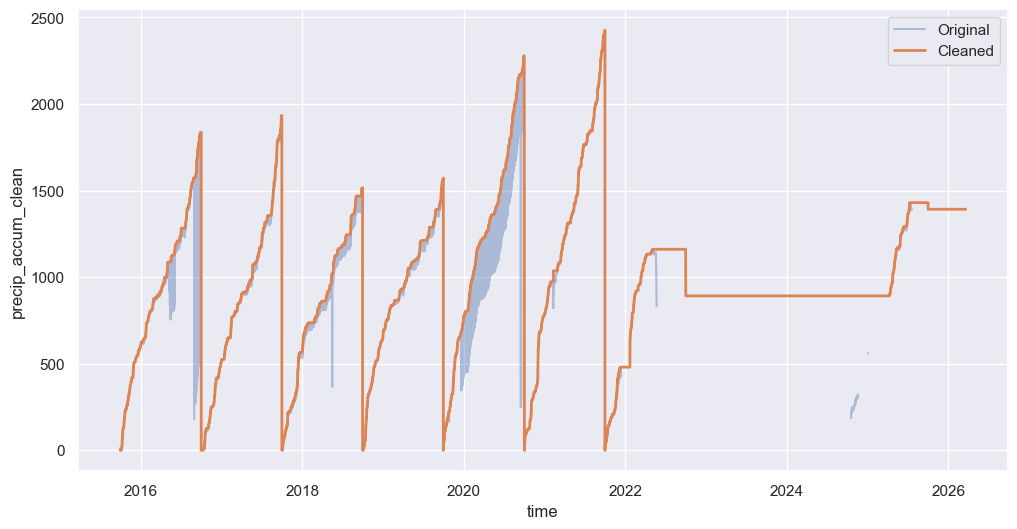

In [174]:
import numpy as np
import xarray as xr

# -----------------------------------------------------------------------------
# Clean accumulated precipitation for multiple water years
# Allows reset near Oct 1 every year
# -----------------------------------------------------------------------------

ds_met_heen_clean['precip_accum'] = ds_met_heen_clean['precip1'] * 25.4  # Convert inches to mm

# Copy original accumulated precipitation
accum = ds_met_heen_clean['precip_accum'].copy()

# Calculate timestep differences
diffs = accum.diff(dim='time')

# -----------------------------------------------------------------------------
# Define valid Water Year reset window
# Allow decreases during Oct 1–3 every year
# -----------------------------------------------------------------------------

time_diff = accum['time'].isel(time=slice(1, None))

valid_wy_reset = (
    (time_diff.dt.month == 10) &
    (time_diff.dt.day <= 3)
)

# -----------------------------------------------------------------------------
# Detect bad decreases
# -----------------------------------------------------------------------------

bad_reset = (
    (diffs < 0) &
    (~valid_wy_reset)
)

# -----------------------------------------------------------------------------
# Mask bad decreases
# -----------------------------------------------------------------------------

accum_clean = accum.copy()

accum_clean[1:] = accum_clean[1:].where(~bad_reset, np.nan)

# -----------------------------------------------------------------------------
# Forward fill masked decreases
# -----------------------------------------------------------------------------

accum_clean = accum_clean.ffill(dim='time')

# -----------------------------------------------------------------------------
# Enforce monotonicity WITHIN each water year separately
# -----------------------------------------------------------------------------

years = np.unique(accum_clean['time.year'])

accum_clean_final = accum_clean.copy()

for year in years:

    # Water year:
    # Oct(year-1) -> Sep(year)
    wy_mask = (
        (
            (accum_clean['time.year'] == year - 1) &
            (accum_clean['time.month'] >= 10)
        )
        |
        (
            (accum_clean['time.year'] == year) &
            (accum_clean['time.month'] < 10)
        )
    )

    if wy_mask.sum() == 0:
        continue

    wy_values = accum_clean.where(wy_mask, drop=True).values

    # Enforce cumulative maximum only within WY
    wy_values_clean = np.maximum.accumulate(wy_values)

    accum_clean_final.loc[
        dict(time=accum_clean.where(wy_mask, drop=True).time)
    ] = wy_values_clean

# -----------------------------------------------------------------------------
# Save cleaned accumulated precipitation
# -----------------------------------------------------------------------------

ds_met_heen_clean['precip_accum_clean'] = accum_clean_final

# -----------------------------------------------------------------------------
# Convert accumulated precip -> timestep precip
# -----------------------------------------------------------------------------

precip_timestep = accum_clean_final.diff(dim='time')

# Add first timestep
precip_timestep = xr.concat(
    [
        xr.DataArray(
            [0],
            coords={'time': [accum_clean_final.time.values[0]]},
            dims='time'
        ),
        precip_timestep
    ],
    dim='time'
)

# Remove negative numerical artifacts
precip_timestep = precip_timestep.where(precip_timestep >= 0, 0)

# -----------------------------------------------------------------------------
# Save timestep precipitation
# -----------------------------------------------------------------------------

# ds_met_heen_clean['precip'] = precip_timestep

# -----------------------------------------------------------------------------
# Optional plots
# -----------------------------------------------------------------------------

ds_met_heen_clean['precip_accum'].plot(label='Original', alpha=0.4)

ds_met_heen_clean['precip_accum_clean'].plot(
    label='Cleaned',
    linewidth=2
)

plt.legend()
plt.show()

That worked. Looks great. 

## Cleaning: Unit conversion to match other uses

In [175]:
ds_met_heen_clean

<xarray.Dataset> Size: 10MB
Dimensions:             (time: 83296)
Coordinates:
  * time                (time) datetime64[ns] 666kB 2015-10-01 ... 2026-03-20...
Data variables: (12/14)
    site_id             (time) int32 333kB ...
    swe                 (time) float64 666kB 0.0 13.5 13.5 ... 17.1 17.1 17.1
    precip1             (time) float64 666kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    precip2             (time) float64 666kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    temp                (time) float64 666kB 3.6 3.6 3.3 3.1 ... nan nan nan nan
    hs                  (time) float64 666kB 0.0 0.0 0.0 0.0 ... 77.0 77.0 76.0
    ...                  ...
    ws_x                (time) float64 666kB 3.0 3.0 3.0 2.0 ... nan nan nan nan
    ws_v                (time) float64 666kB 1.0 0.0 0.0 0.0 ... nan nan nan nan
    rh                  (time) float64 666kB 100.0 99.0 99.0 ... nan nan nan
    pres                (time) float64 666kB nan nan nan nan ... nan nan nan nan
    precip_accum        (time) float64 666kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    precip_accum_clean  (time) float64 666kB 0.0 0.0 0.0 ... 1.392e+03 1.392e+03

Deal with vars and units, 

In [176]:
# make a version of ds_met_heen_clean which converts all the variables to the same units as expected by SNOWPACK 
# # --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa

In [177]:
# CLeaning first, 
ds_met_heen_clean = ds_met_heen_clean.copy()
ds_met_heen_clean["temp"] = ds_met_heen_clean["temp"] + 273.15 # convert from C to K
ds_met_heen_clean["wind"] = ds_met_heen_clean["ws_v"] * 0.44704 # convert from mph to m/s
ds_met_heen_clean["wind_dir"] = (270 - ds_met_heen_clean["wdir"]) % 360 # convert from degrees (meteorological to mathematical)
# ds_met_heen_clean["precip_accum"] = ds_met_heen_clean["precip1"] * 25.4 # convert from inches to mm, # ALREADY DEALT WITH PRECIP
ds_met_heen_clean["pressure"] = ds_met_heen_clean["pres"] * 100. # convert from mbar to Pa

# and convert swe and hs to cm 
ds_met_heen_clean["swe"] = ds_met_heen_clean["swe"] * 2.54 # convert from inches to cm
ds_met_heen_clean["hs"] = ds_met_heen_clean["hs"] * 2.54 # convert from inches to cm

# PRECIP
# now we need to deal with precip
# we have total accumulated precip but we need precip per timestep for SNOWPACK 
# so first, calculate precip_rate from precip_accum (hourly timestep)
ds_met_heen_clean["precip_rate"] = ds_met_heen_clean["precip_accum_clean"].diff("time") / 3600.0 # convert from mm/hr to mm/s for SNOWPACK
# and it can never be negative, so set any negative values to 0
ds_met_heen_clean["precip_rate"] = ds_met_heen_clean["precip_rate"].where(ds_met_heen_clean["precip_rate"] >= 0, 0)

# and if it is greater than 100 then set to nan
ds_met_heen_clean["precip_rate"] = ds_met_heen_clean["precip_rate"].where(ds_met_heen_clean["precip_rate"] < 0.04, np.nan)

# now calculate precip_accum_1hr for comparison with the HRRRAK precip variable (which is in mm/s but we can convert to mm/hr)
ds_met_heen_clean["precip_accum_1hr"] = ds_met_heen_clean["precip_rate"] * 3600 # convert from mm/s to mm/hr for comparison with the observed data

# and if it is greater than 100 then set to nan
ds_met_heen_clean["precip_accum_1hr"] = ds_met_heen_clean["precip_accum_1hr"].where(ds_met_heen_clean["precip_accum_1hr"] < 100, np.nan)

# Final cleaning, 
# delete a few variables to make this cleaner
ds_met_heen_clean = ds_met_heen_clean.drop_vars(['site_id', 'precip1', 'precip2', 'bat', 'pres', 'wdir', 'ws_v', 'ws_x']) # dropping wdir and ws_v since we have created new variables for wind direction and wind speed


# add attributes to the new variables
ds_met_heen_clean["temp"].attrs['units'] = 'K'
ds_met_heen_clean["rh"].attrs['units'] = 'percent'
ds_met_heen_clean["wind"].attrs['units'] = 'm/s'
ds_met_heen_clean["wind_dir"].attrs['units'] = 'degrees (mathematical)'
ds_met_heen_clean["precip_accum"].attrs['units'] = 'mm'
ds_met_heen_clean["pressure"].attrs['units'] = 'Pa'
ds_met_heen_clean["swe"].attrs['units'] = 'cm'
ds_met_heen_clean["hs"].attrs['units'] = 'cm'

# Plot the Final Cleaned Dataset

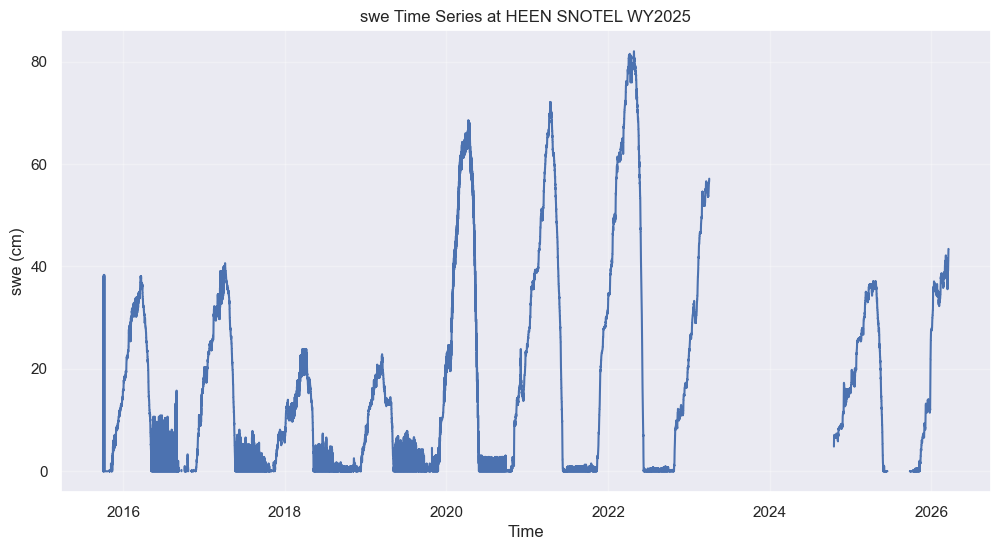

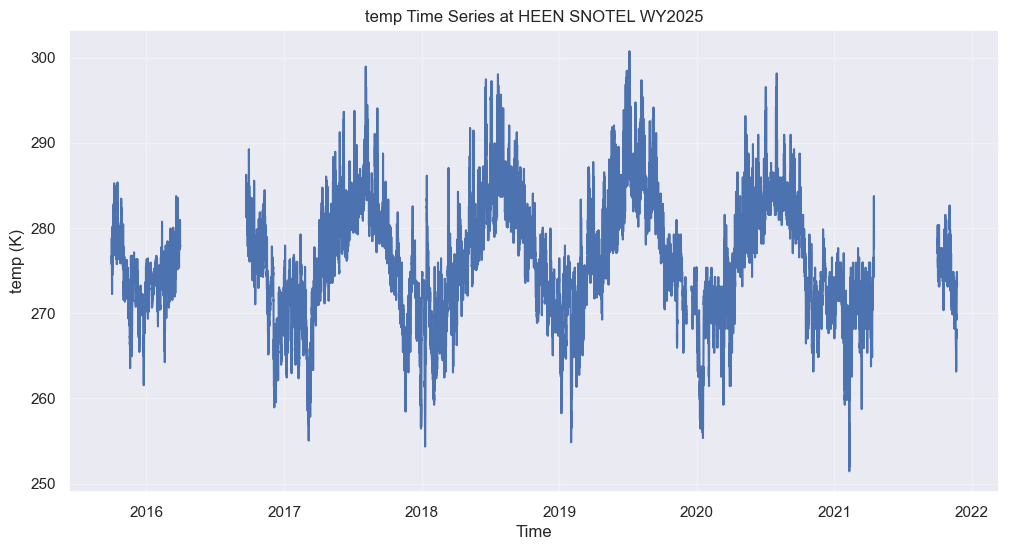

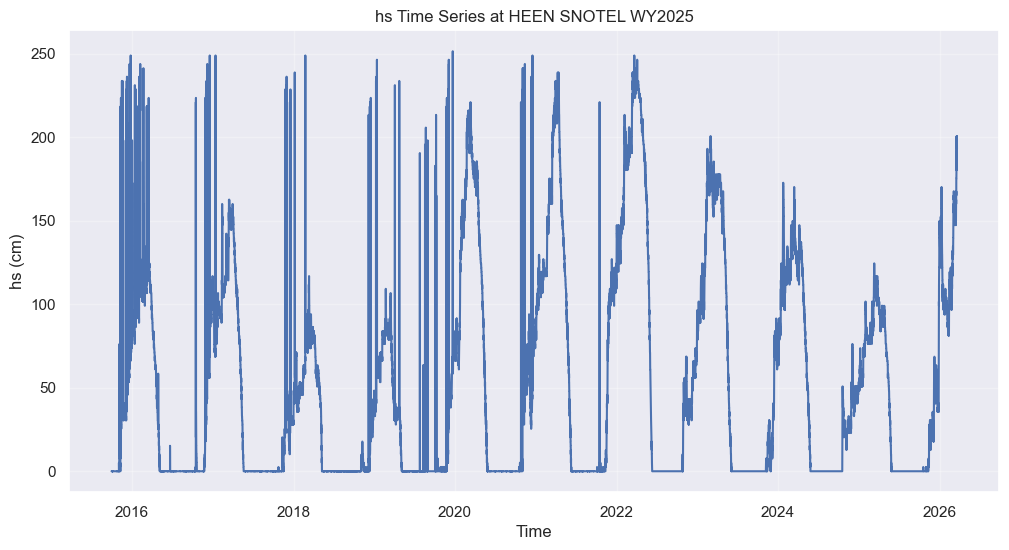

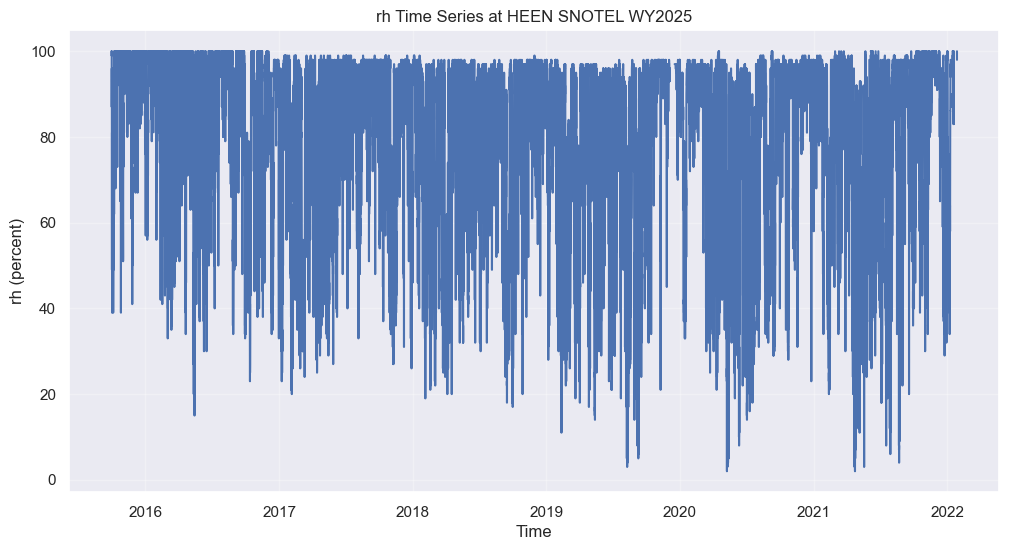

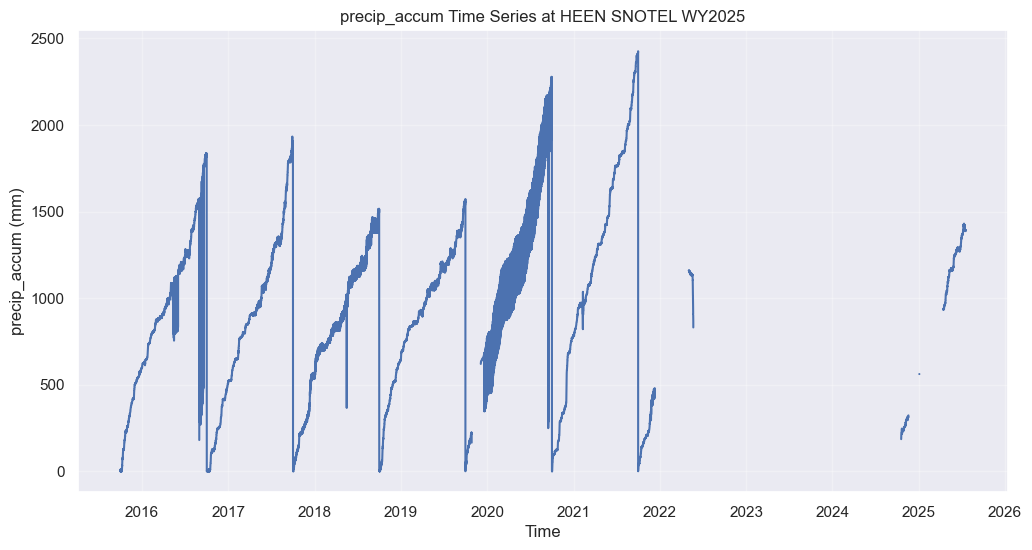

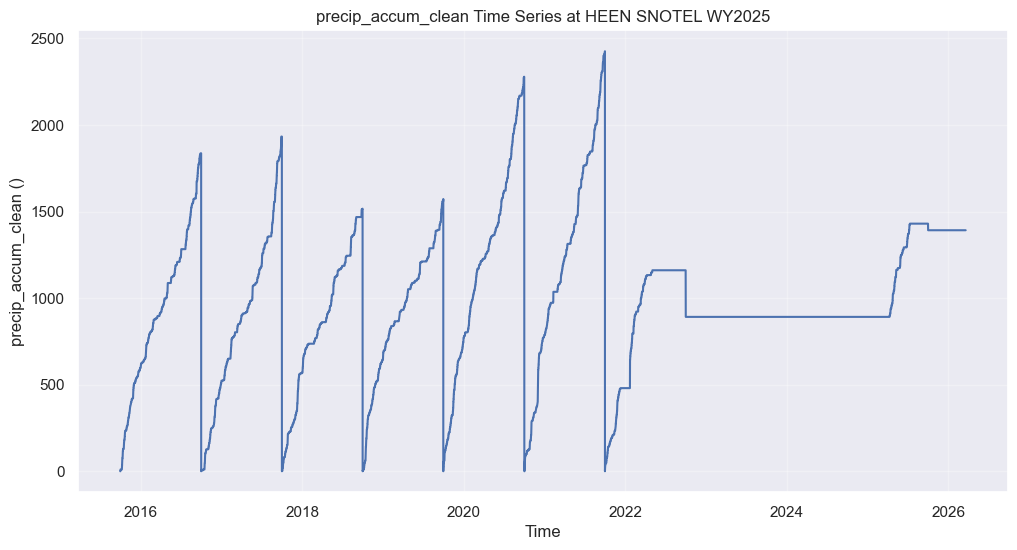

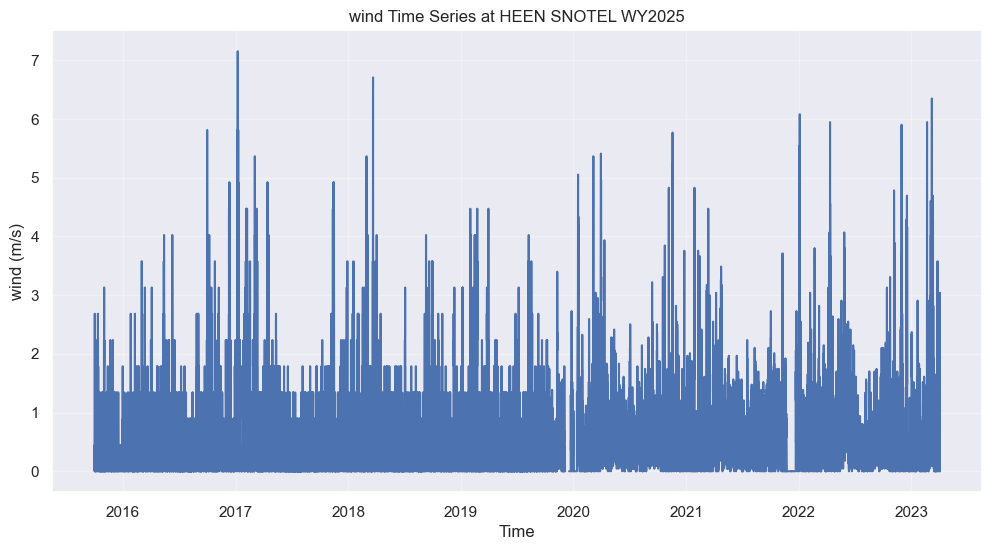

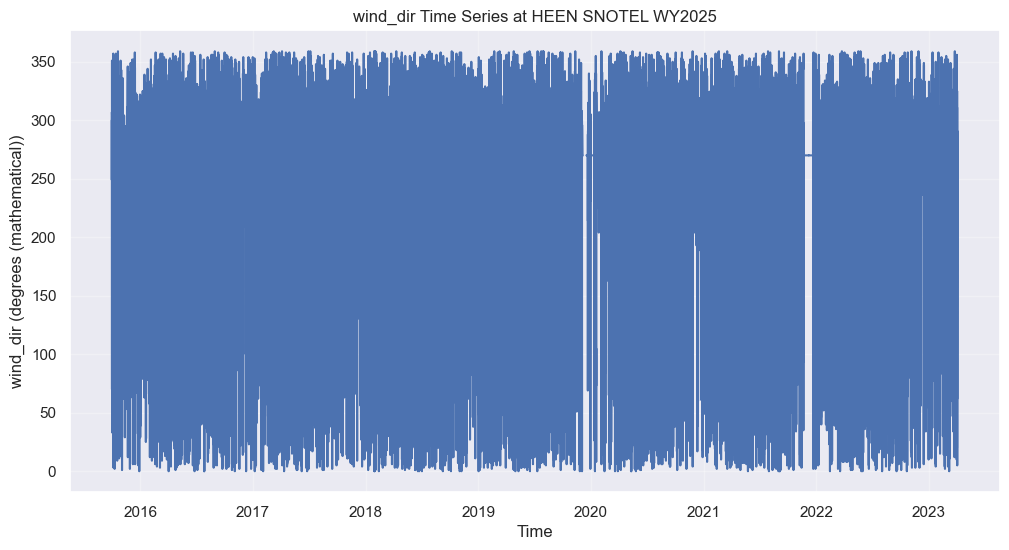

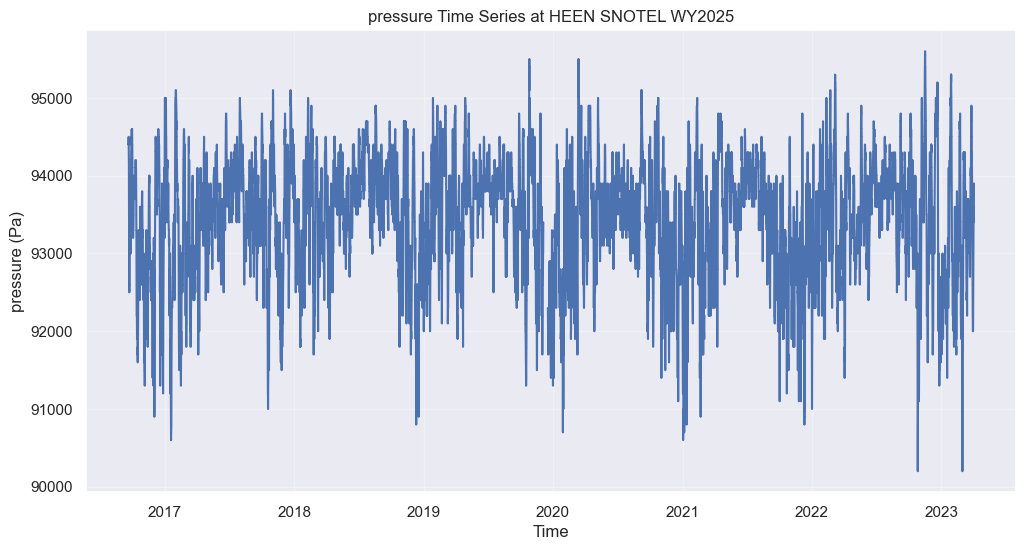

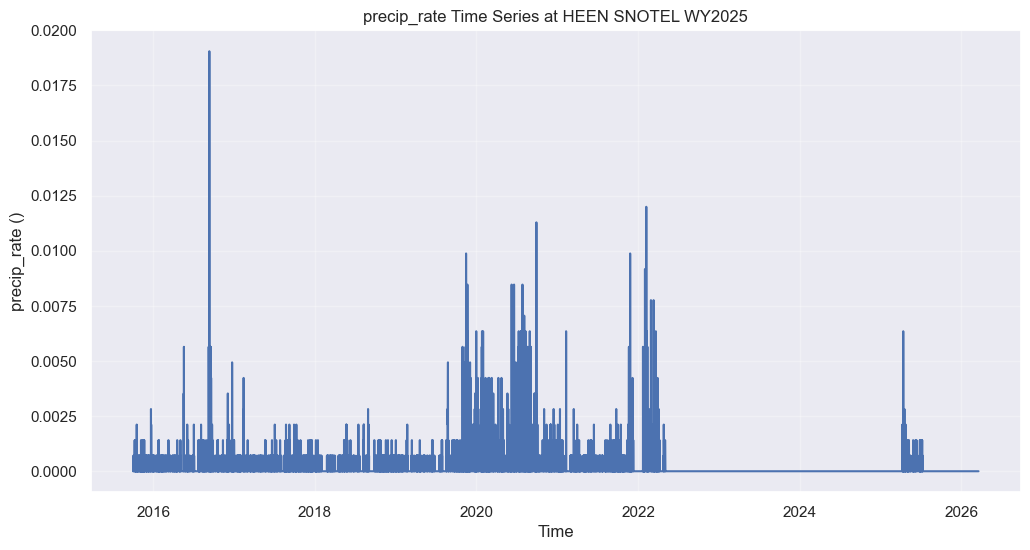

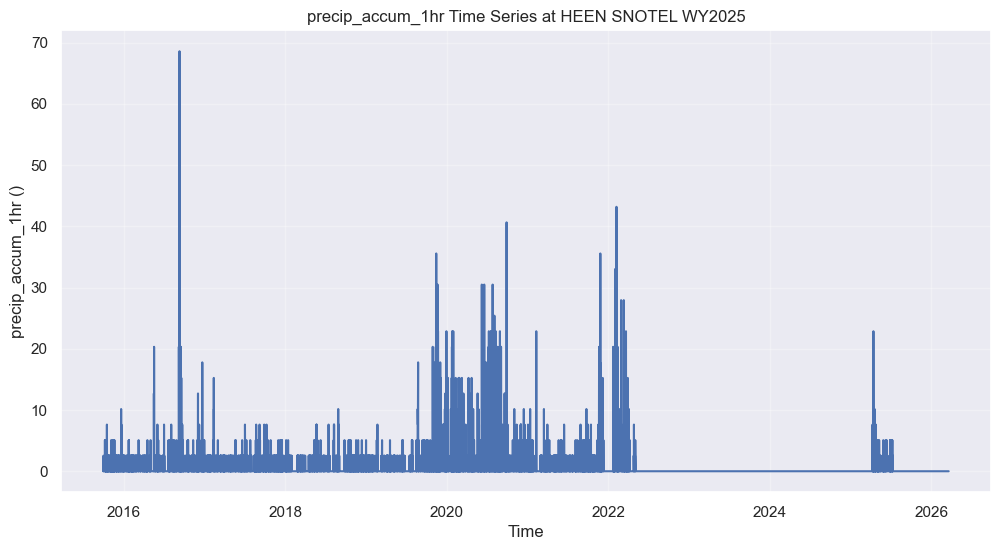

In [178]:
# plot all the variables to see what we have and how they look
for var in ds_met_heen_clean.data_vars:
    plt.figure()
    ds_met_heen_clean[var].plot()
    plt.title(f"{var} Time Series at HEEN SNOTEL WY2025")
    plt.xlabel("Time")
    plt.ylabel(f"{var} ({ds_met_heen_clean[var].attrs.get('units', '')})")
    plt.grid(True, alpha=0.3)
    plt.show()
    

# Last Cleaning: Snow Depth & SWE

### Snow depth first, 

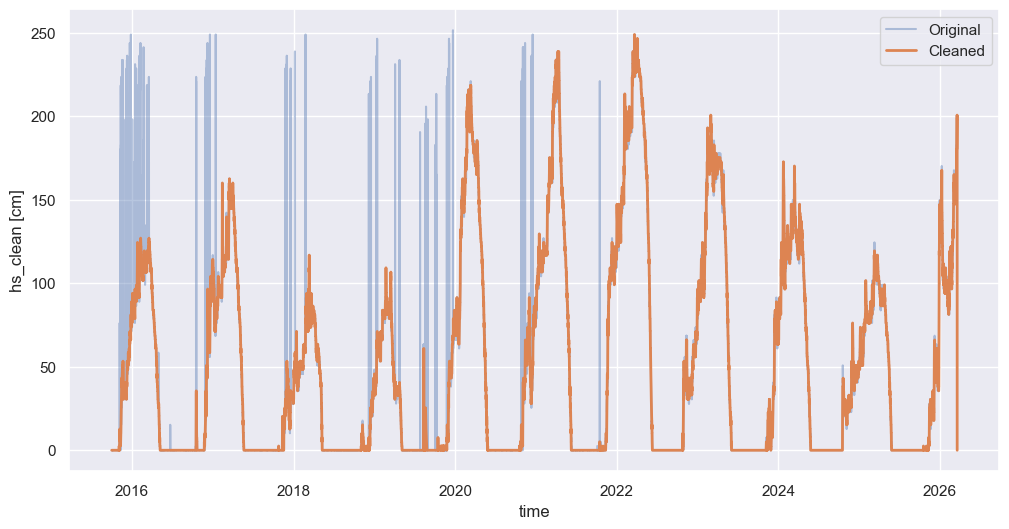

In [179]:
# -----------------------------------------------------------------------------
# CLEAN SNOW DEPTH (hs)
# -----------------------------------------------------------------------------

hs = ds_met_heen_clean['hs'].copy()

# Calculate timestep changes
dhs = hs.diff(dim='time')

# -----------------------------------------------------------------------------
# Define physically unrealistic changes
# -----------------------------------------------------------------------------

max_increase = 15.0   # cm per timestep
max_decrease = -20.0 # cm per timestep

bad_change = (
    (dhs > max_increase) |
    (dhs < max_decrease)
)

# Align dimensions
bad_change = xr.concat(
    [
        xr.DataArray(
            [False],
            coords={'time': [hs.time.values[0]]},
            dims='time'
        ),
        bad_change
    ],
    dim='time'
)

# -----------------------------------------------------------------------------
# Mask bad spikes
# -----------------------------------------------------------------------------

hs_clean = hs.where(~bad_change)

# -----------------------------------------------------------------------------
# Rolling median filter
# centered 5-point window
# -----------------------------------------------------------------------------

hs_clean = (
    hs_clean
    .rolling(time=5, center=True)
    .median()
)

# -----------------------------------------------------------------------------
# Fill gaps after filtering
# -----------------------------------------------------------------------------

hs_clean = hs_clean.interpolate_na(
    dim='time',
    method='linear'
)

# -----------------------------------------------------------------------------
# Remove tiny negatives
# -----------------------------------------------------------------------------

hs_clean = hs_clean.where(hs_clean >= 0, 0)

# -----------------------------------------------------------------------------
# Save
# -----------------------------------------------------------------------------

ds_met_heen_clean['hs_clean'] = hs_clean

# plot the two to compare 
plt.figure()
ds_met_heen_clean['hs'].plot(label='Original', alpha=0.4)
ds_met_heen_clean['hs_clean'].plot(label='Cleaned', linewidth=2)
plt.legend()

### And now, with SWE too, mostly focusing on removing those spikes in the summer

In [180]:
# -----------------------------------------------------------------------------
# INPUT
# -----------------------------------------------------------------------------

hs = ds_met_heen_clean['hs_clean'].copy()

# -----------------------------------------------------------------------------
# PARAMETERS
# -----------------------------------------------------------------------------

snow_off_thresh = 2.0      # cm
snow_on_thresh = 5.0       # cm
persistence_hours = 24     # hours

# -----------------------------------------------------------------------------
# Detect persistent snow cover
# -----------------------------------------------------------------------------

snow_present = hs > snow_on_thresh

# Require persistence
snow_present_persist = (
    snow_present
    .rolling(time=persistence_hours, center=False)
    .sum()
) >= persistence_hours

# -----------------------------------------------------------------------------
# Initialize cleaned array
# -----------------------------------------------------------------------------

hs_season_clean = hs.copy()

in_summer_mode = False

values = hs.values.copy()
snow_persist_vals = snow_present_persist.fillna(False).values

# -----------------------------------------------------------------------------
# Loop through time
# -----------------------------------------------------------------------------

for i in range(len(values)):

    val = values[i]

    # ---------------------------------------------------------
    # Detect transition into snow-free season
    # ---------------------------------------------------------

    if not in_summer_mode:

        if val < snow_off_thresh:
            in_summer_mode = True

    # ---------------------------------------------------------
    # Summer mode: suppress noise spikes
    # ---------------------------------------------------------

    else:

        # Stay at zero unless persistent snow returns
        if snow_persist_vals[i]:
            in_summer_mode = False
        else:
            values[i] = 0.0

# -----------------------------------------------------------------------------
# Save
# -----------------------------------------------------------------------------

hs_season_clean.values = values

ds_met_heen_clean['hs_final'] = hs_season_clean

### Same for SWE

In [181]:
# ------------------------------------------------------------
# INPUT
# ------------------------------------------------------------
swe = ds_met_heen_clean['swe'].copy()

# ------------------------------------------------------------
# THRESHOLDS (tune as needed)
# ------------------------------------------------------------
snow_off_thresh = 3.0   # mm SWE below this → considered snow-free
snow_on_thresh  = 5.0  # mm SWE above this → snow presence candidate

# ------------------------------------------------------------
# STEP 1: Detect potential snow presence (binary signal)
# ------------------------------------------------------------
snow_present = swe > snow_on_thresh

# ------------------------------------------------------------
# STEP 2: Require persistence to avoid noise / spikes
# (snow must persist for 24 timesteps before being valid)
# ------------------------------------------------------------
snow_present_persist = (
    snow_present.rolling(time=24, center=False).sum()
) >= 24

snow_mask = snow_present_persist.fillna(False).values
swe_values = swe.values

# ------------------------------------------------------------
# STEP 3: Build seasonal mask (KEY FIX)
# ------------------------------------------------------------
# This creates continuous "snow seasons" and ensures:
#   - we capture first accumulation (backfill)
#   - we preserve full seasonal evolution
#   - we remove only true off-season periods

season_mask = np.zeros_like(snow_mask, dtype=bool)

in_season = False

for i in range(len(snow_mask)):

    # --------------------------------------------------------
    # CASE 1: START OF SEASON
    # --------------------------------------------------------
    if not in_season and snow_mask[i]:

        in_season = True
        season_mask[i] = True

        # BACKFILL: include early accumulation leading into season
        j = i - 1
        while j >= 0:

            # keep values that are physically part of snowpack buildup
            if swe_values[j] > snow_off_thresh:
                season_mask[j] = True
                j -= 1
            else:
                break

    # --------------------------------------------------------
    # CASE 2: INSIDE SEASON
    # --------------------------------------------------------
    elif in_season:
        season_mask[i] = True

        # ----------------------------------------------------
        # END OF SEASON CONDITION
        # snow mask no longer persistent
        # ----------------------------------------------------
        if not snow_mask[i]:
            in_season = False

# ------------------------------------------------------------
# STEP 4: Apply mask
# ------------------------------------------------------------
swe_final = swe.copy()

# Keep values inside season, zero everything else
swe_final.values = np.where(season_mask, swe_values, 0.0)

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------
ds_met_heen_clean['swe_final'] = swe_final

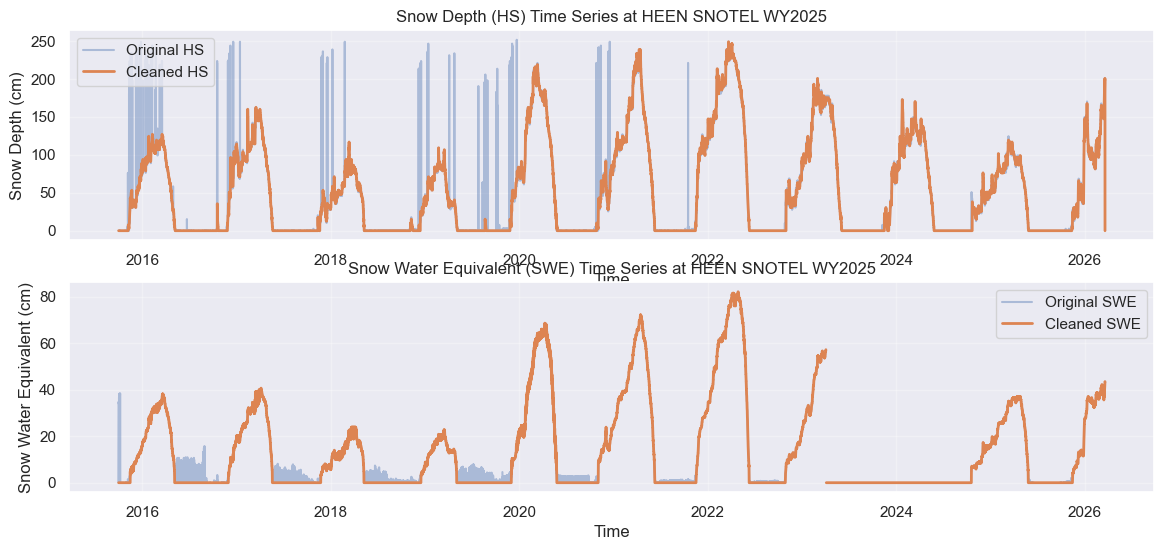

In [182]:
# plot both hs and swe original and final to compare
plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
ds_met_heen_clean['hs'].plot(label='Original HS', alpha=0.4)
ds_met_heen_clean['hs_final'].plot(label='Cleaned HS', linewidth=2)
plt.legend()
plt.title('Snow Depth (HS) Time Series at HEEN SNOTEL WY2025')
plt.xlabel('Time')  
plt.ylabel('Snow Depth (cm)')
plt.grid(True, alpha=0.3)
plt.subplot(2, 1, 2)
ds_met_heen_clean['swe'].plot(label='Original SWE', alpha=0.4)
ds_met_heen_clean['swe_final'].plot(label='Cleaned SWE', linewidth=2)
plt.legend()
plt.title('Snow Water Equivalent (SWE) Time Series at HEEN SNOTEL WY2025')
plt.xlabel('Time')
plt.ylabel('Snow Water Equivalent (cm)')
plt.grid(True, alpha=0.3)

## Save the final variables to the correst locations

In [183]:
ds_met_heen_clean

<xarray.Dataset> Size: 10MB
Dimensions:             (time: 83296)
Coordinates:
  * time                (time) datetime64[ns] 666kB 2015-10-01 ... 2026-03-20...
Data variables: (12/14)
    swe                 (time) float64 666kB 0.0 34.29 34.29 ... 43.43 43.43
    temp                (time) float64 666kB 276.8 276.8 276.4 ... nan nan nan
    hs                  (time) float64 666kB 0.0 0.0 0.0 ... 195.6 195.6 193.0
    rh                  (time) float64 666kB 100.0 99.0 99.0 ... nan nan nan
    precip_accum        (time) float64 666kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    precip_accum_clean  (time) float64 666kB 0.0 0.0 0.0 ... 1.392e+03 1.392e+03
    ...                  ...
    pressure            (time) float64 666kB nan nan nan nan ... nan nan nan nan
    precip_rate         (time) float64 666kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precip_accum_1hr    (time) float64 666kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    hs_clean            (time) float64 666kB 0.0 0.0 0.0 0.0 ... 195.6 0.0 0.0
    hs_final            (time) float64 666kB 0.0 0.0 0.0 0.0 ... 195.6 0.0 0.0
    swe_final           (time) float64 666kB 0.0 0.0 0.0 ... 43.43 43.43 43.43

In [184]:
# great, now ds_met_heen_clean is now cleaned, so we can replace the origional variables with the cleaned versions and drop the intermediate variables if we want to make it cleaner for SNOWPACK input.
ds_met_heen_clean['hs'] = ds_met_heen_clean['hs_clean']
ds_met_heen_clean = ds_met_heen_clean.drop_vars('hs_clean')

# same for precip_accum 
ds_met_heen_clean['precip_accum'] = ds_met_heen_clean['precip_accum_clean']
ds_met_heen_clean = ds_met_heen_clean.drop_vars('precip_accum_clean')

# for hs and swe the final are hs_final and swe_final, so replace those 
ds_met_heen_clean['hs'] = ds_met_heen_clean['hs_final']
ds_met_heen_clean = ds_met_heen_clean.drop_vars('hs_final')

ds_met_heen_clean['swe'] = ds_met_heen_clean['swe_final']
ds_met_heen_clean = ds_met_heen_clean.drop_vars('swe_final')

In [185]:
ds_met_heen_clean

<xarray.Dataset> Size: 7MB
Dimensions:           (time: 83296)
Coordinates:
  * time              (time) datetime64[ns] 666kB 2015-10-01 ... 2026-03-20T0...
Data variables:
    swe               (time) float64 666kB 0.0 0.0 0.0 0.0 ... 43.43 43.43 43.43
    temp              (time) float64 666kB 276.8 276.8 276.4 ... nan nan nan
    hs                (time) float64 666kB 0.0 0.0 0.0 0.0 ... 195.6 0.0 0.0
    rh                (time) float64 666kB 100.0 99.0 99.0 100.0 ... nan nan nan
    precip_accum      (time) float64 666kB 0.0 0.0 0.0 ... 1.392e+03 1.392e+03
    wind              (time) float64 666kB 0.447 0.0 0.0 0.0 ... nan nan nan nan
    wind_dir          (time) float64 666kB 300.0 257.0 249.0 ... nan nan nan
    pressure          (time) float64 666kB nan nan nan nan ... nan nan nan nan
    precip_rate       (time) float64 666kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precip_accum_1hr  (time) float64 666kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

# Save to a new file

In [186]:
# save the first version of the cleaned data 
# file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/site1270_hourly_2016_2026.nc" # original file path
file_heen_clean = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/heen_met_2016_2026_cleaned_v1.nc"
ds_met_heen_clean.to_netcdf(file_heen_clean)

In [187]:
# now cut the dataset to be years we might use, from WY2018 to WY2022
ds_met_heen_clean = ds_met_heen_clean.sel(time=slice("2018-10-01", "2022-09-30"))

# and save to a new netcdf
file_heen_clean_cut = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/heen_met_2018_2022_cleaned_v2.nc"
ds_met_heen_clean.to_netcdf(file_heen_clean_cut)

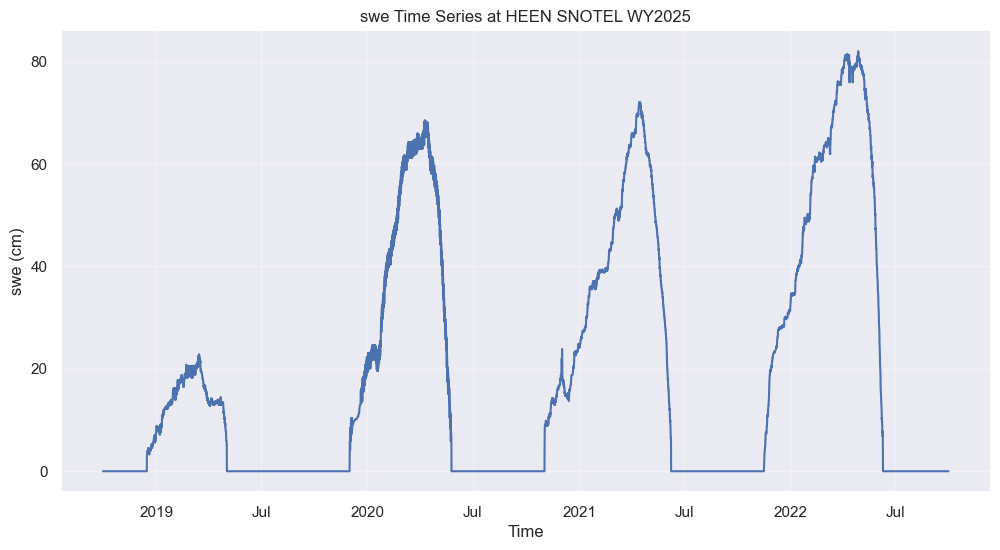

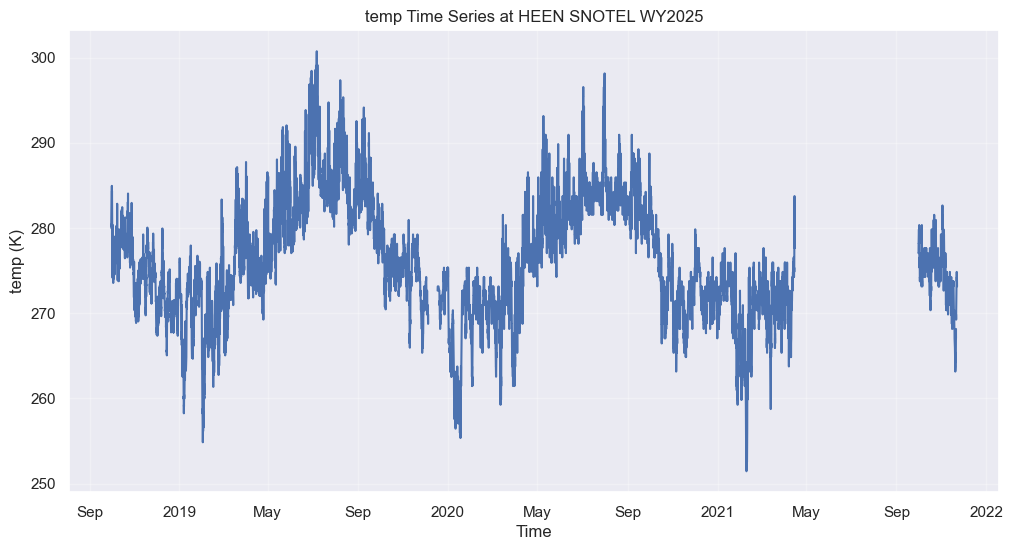

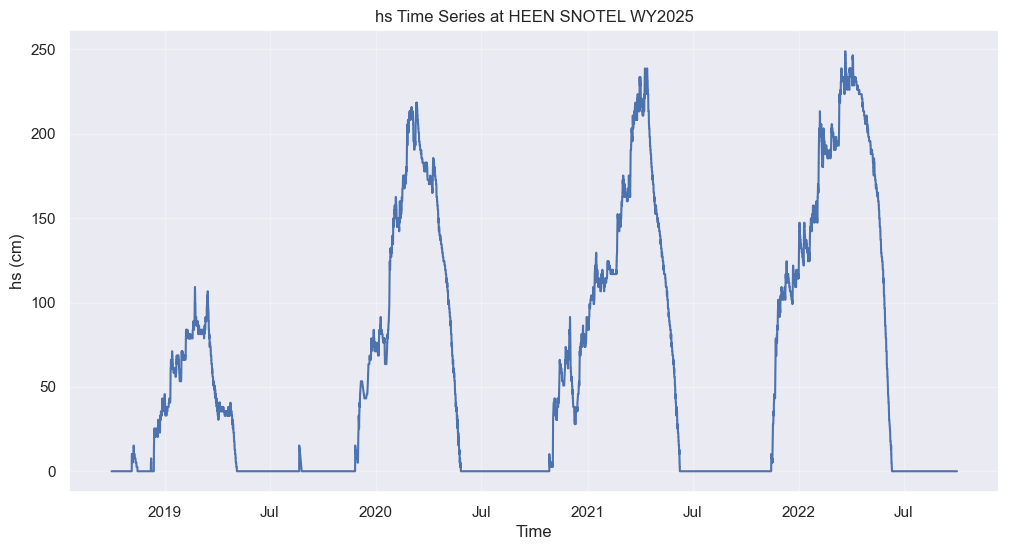

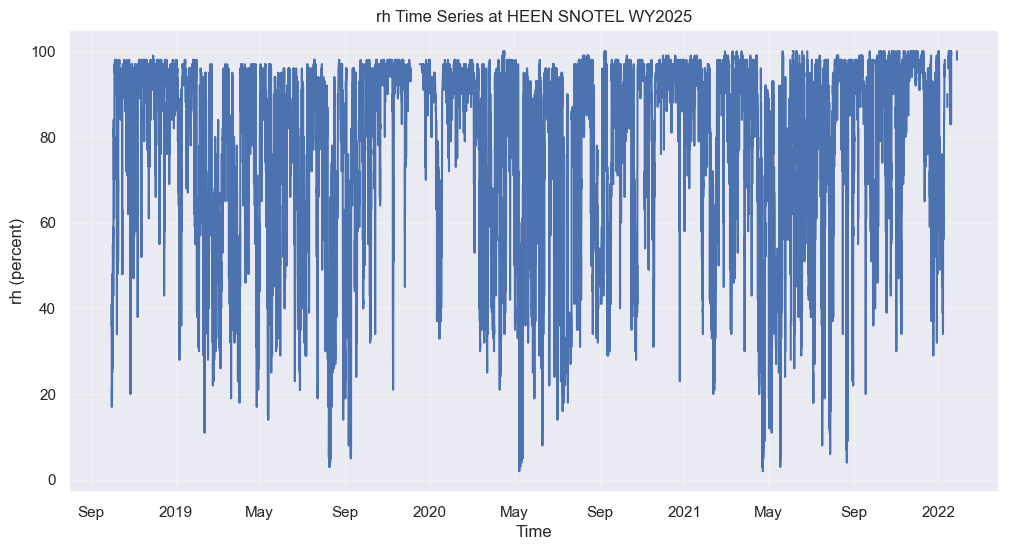

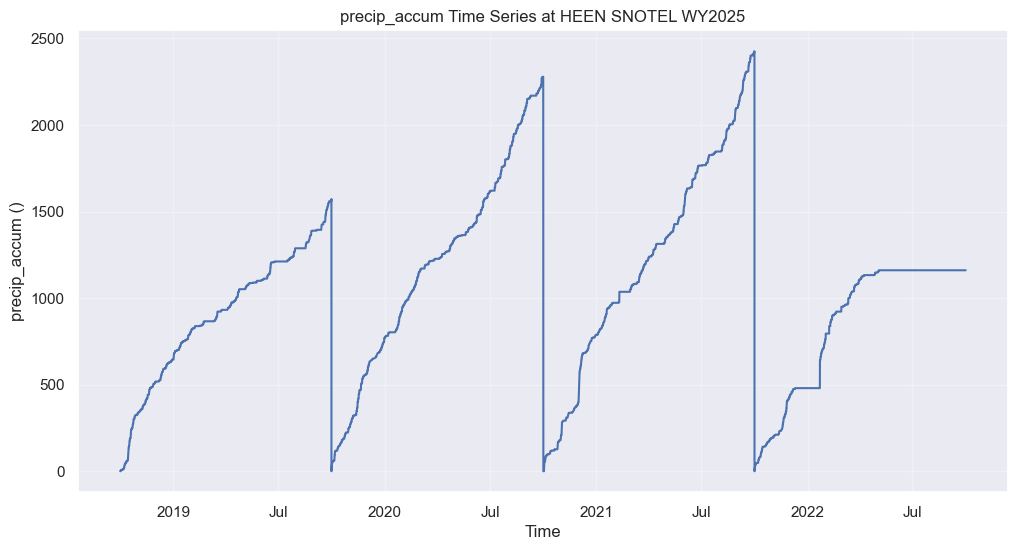

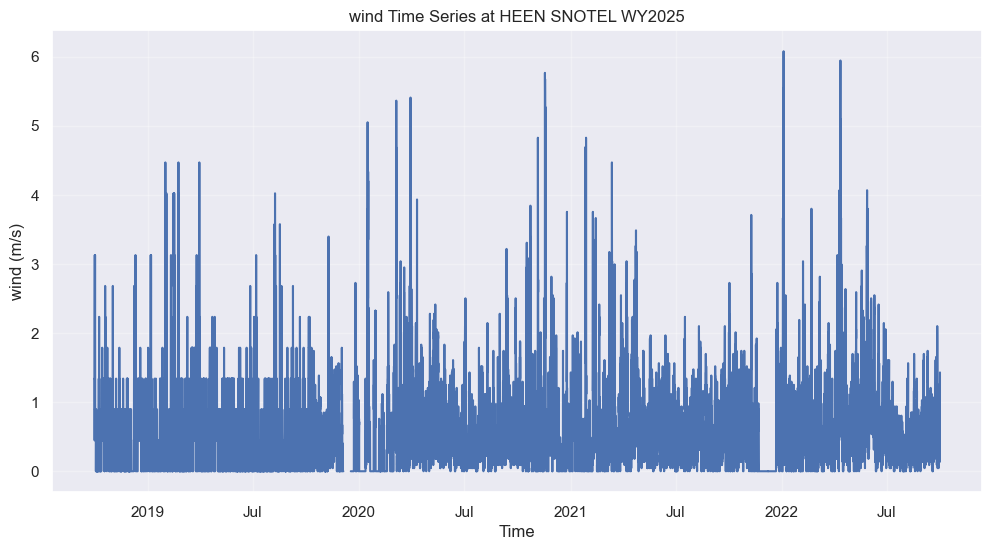

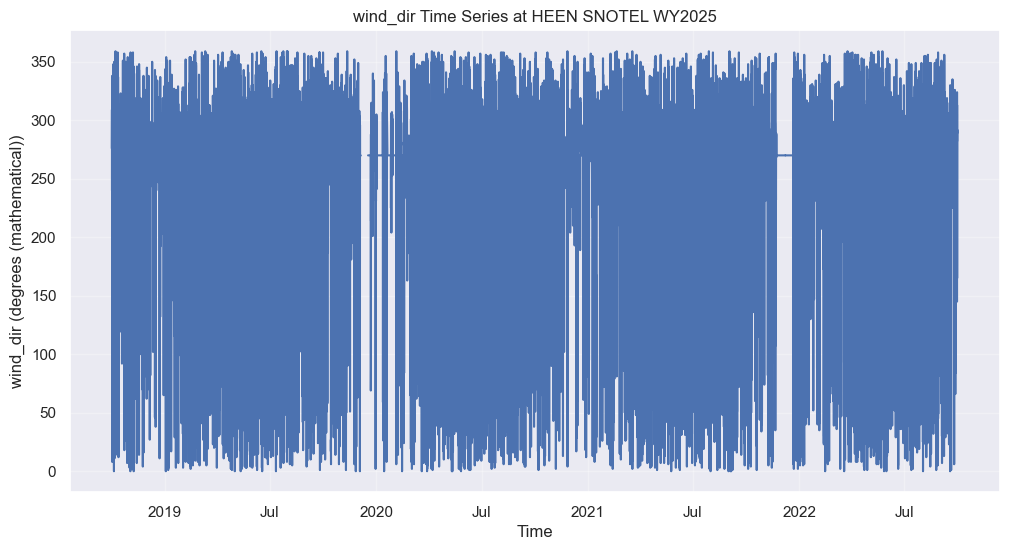

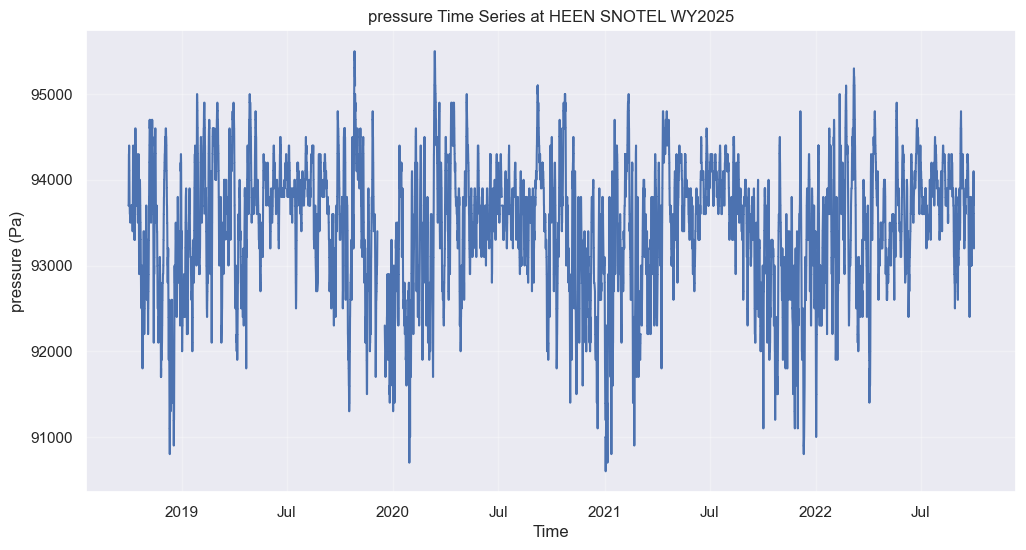

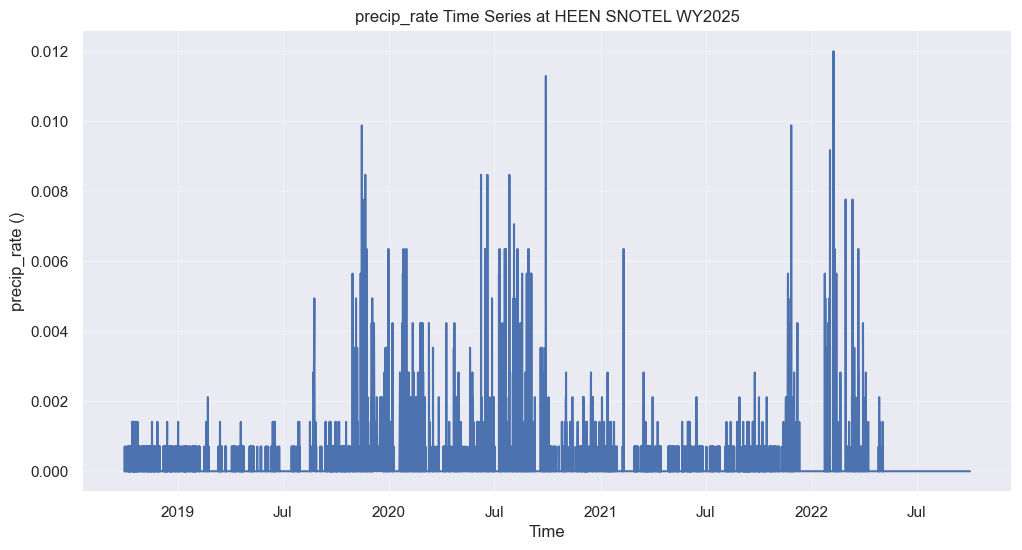

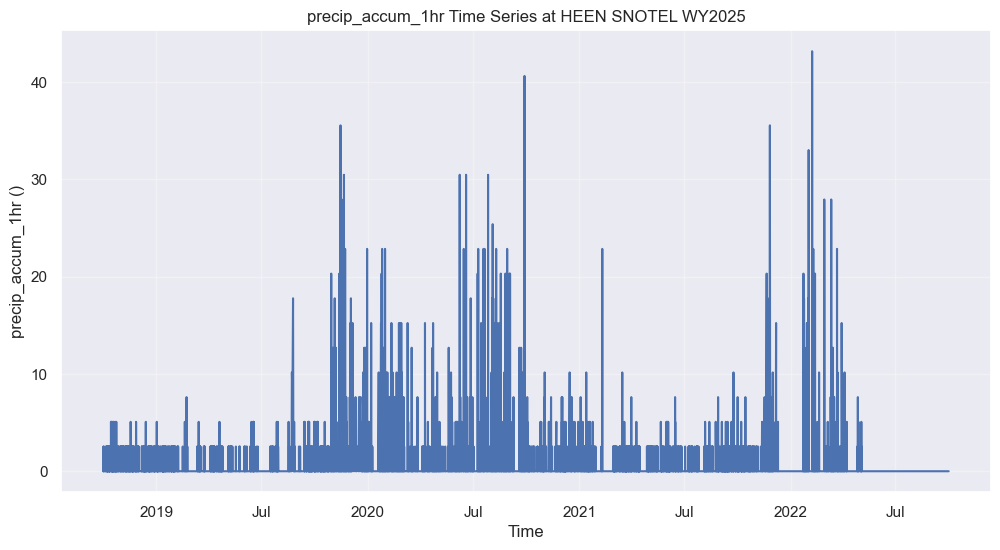

In [188]:
# plot all the variables to see what we have and how they look
for var in ds_met_heen_clean.data_vars:
    plt.figure()
    ds_met_heen_clean[var].plot()
    plt.title(f"{var} Time Series at HEEN SNOTEL WY2025")
    plt.xlabel("Time")
    plt.ylabel(f"{var} ({ds_met_heen_clean[var].attrs.get('units', '')})")
    plt.grid(True, alpha=0.3)
    plt.show()
    